# MNPS Job Classification Likelihood Scorer - Individual Record Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yourusername/yourrepo/blob/main/MNPS_Job_Classification_Likelihood_Scorer_v2.ipynb)

## Purpose
This notebook calculates likelihood scores (0-5 scale) for **EACH** job classification record, comparing AI model performance to human HR professionals (88-94% baseline accuracy).

### Key Features:
- 📊 Individual likelihood scores for every record
- 💾 Google Drive integration for saving results
- 📦 Automatic handling of zipped resource files
- 📈 Detailed visualizations and analysis
- 📁 Export results to CSV for further analysis

### Required Files:
1. **Evaluation Resources.zip** (contains static resource files - rarely changes)
2. **Job Descriptions CSV** (your input batch - changes each run)
3. **Classifications CSV** (model output - changes each run)

---

In [1]:
#@title 1️⃣ Mount Google Drive and Setup Environment { display-mode: "form" }
#@markdown This cell mounts your Google Drive and sets up the working environment

from google.colab import drive
import os
import datetime
import zipfile
import shutil

# Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')

# Create directory structure in Google Drive
base_path = '/content/drive/MyDrive/MNPS_Likelihood_Analysis'
if not os.path.exists(base_path):
    os.makedirs(base_path)
    print(f"✅ Created base directory: {base_path}")

# Create subdirectories
resources_path = os.path.join(base_path, 'Resources')
results_path = os.path.join(base_path, 'Results')
inputs_path = os.path.join(base_path, 'Inputs')

for path in [resources_path, results_path, inputs_path]:
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"✅ Created: {path}")

# Create timestamped results folder for this run
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
run_results_path = os.path.join(results_path, f'Run_{timestamp}')
os.makedirs(run_results_path)
print(f"📁 Results will be saved to: {run_results_path}")

# Set working directory
os.chdir('/content')
print("\n✅ Google Drive mounted and directories created!")
print(f"📂 Main folder: {base_path}")
print(f"📊 This run's results: {run_results_path}")

🔗 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Results will be saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_20251117_213734

✅ Google Drive mounted and directories created!
📂 Main folder: /content/drive/MyDrive/MNPS_Likelihood_Analysis
📊 This run's results: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_20251117_213734


In [2]:
#@title 2️⃣ Install Dependencies and Import Libraries { display-mode: "form" }
#@markdown Install required packages and import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import warnings
import json
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Dependencies installed and imported successfully!")
print("=" * 80)

✅ Dependencies installed and imported successfully!


In [3]:
#@title 3️⃣ Configuration Parameters { display-mode: "form" }
#@markdown Adjust the human baseline accuracy range and component weights

HUMAN_BASELINE_MIN = 88 #@param {type:"slider", min:80, max:95, step:1}
HUMAN_BASELINE_MAX = 94 #@param {type:"slider", min:85, max:99, step:1}
HUMAN_BASELINE_TYPICAL = (HUMAN_BASELINE_MIN + HUMAN_BASELINE_MAX) / 2

#@markdown ### Component Weights (must sum to 100%)
WEIGHT_KSAC_SIMILARITY = 40 #@param {type:"slider", min:0, max:100, step:5}
WEIGHT_SALARY_IMPACT = 20 #@param {type:"slider", min:0, max:100, step:5}
WEIGHT_TIME_IMPACT = 10 #@param {type:"slider", min:0, max:100, step:5}
WEIGHT_SUBGROUP = 15 #@param {type:"slider", min:0, max:100, step:5}
WEIGHT_JUSTIFICATION = 15 #@param {type:"slider", min:0, max:100, step:5}

# Normalize weights
total_weight = WEIGHT_KSAC_SIMILARITY + WEIGHT_SALARY_IMPACT + WEIGHT_TIME_IMPACT + WEIGHT_SUBGROUP + WEIGHT_JUSTIFICATION
weights = {
    'similarity': WEIGHT_KSAC_SIMILARITY / total_weight,
    'salary': WEIGHT_SALARY_IMPACT / total_weight,
    'time': WEIGHT_TIME_IMPACT / total_weight,
    'subgroup': WEIGHT_SUBGROUP / total_weight,
    'justification': WEIGHT_JUSTIFICATION / total_weight
}

# Save configuration to Drive
config = {
    'timestamp': timestamp,
    'human_baseline': {
        'min': HUMAN_BASELINE_MIN,
        'max': HUMAN_BASELINE_MAX,
        'typical': HUMAN_BASELINE_TYPICAL
    },
    'weights': weights,
    'weights_raw': {
        'KSAC_SIMILARITY': WEIGHT_KSAC_SIMILARITY,
        'SALARY_IMPACT': WEIGHT_SALARY_IMPACT,
        'TIME_IMPACT': WEIGHT_TIME_IMPACT,
        'SUBGROUP': WEIGHT_SUBGROUP,
        'JUSTIFICATION': WEIGHT_JUSTIFICATION
    }
}

config_file = os.path.join(run_results_path, 'configuration.json')
with open(config_file, 'w') as f:
    json.dump(config, f, indent=2)

print("📊 Configuration Settings:")
print("=" * 50)
print(f"Human Baseline:")
print(f"  • Minimum: {HUMAN_BASELINE_MIN}%")
print(f"  • Maximum: {HUMAN_BASELINE_MAX}%")
print(f"  • Typical: {HUMAN_BASELINE_TYPICAL:.1f}%")
print(f"\nComponent Weights (normalized):")
for component, weight in weights.items():
    print(f"  • {component.capitalize()}: {weight*100:.1f}%")
print(f"\n💾 Configuration saved to Google Drive")

📊 Configuration Settings:
Human Baseline:
  • Minimum: 88%
  • Maximum: 94%
  • Typical: 91.0%

Component Weights (normalized):
  • Similarity: 40.0%
  • Salary: 20.0%
  • Time: 10.0%
  • Subgroup: 15.0%
  • Justification: 15.0%

💾 Configuration saved to Google Drive


In [4]:
#@title 4️⃣ Upload and Extract Evaluation Resources (Zip File) { display-mode: "form" }
#@markdown Upload your "Evaluation Resources.zip" file containing the resource files

print("📦 Please upload your 'Evaluation Resources.zip' file")
print("This should contain:")
print("  • MNPS KSACs.csv")
print("  • MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv")
print("  • salary_by_major_role_grouping.csv")
print("  • Time to correct an error in hours.csv")
print("\n⏳ Waiting for file upload...")

# Upload zip file
uploaded = files.upload()

# Extract zip file
resource_data = {}
temp_extract_path = '/content/temp_resources'

for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f"\n📂 Extracting {filename}...")

        # Create temp directory
        if os.path.exists(temp_extract_path):
            shutil.rmtree(temp_extract_path)
        os.makedirs(temp_extract_path)

        # Extract zip
        with zipfile.ZipFile(io.BytesIO(uploaded[filename]), 'r') as zip_ref:
            zip_ref.extractall(temp_extract_path)

        # Find and load CSV files
        for root, dirs, file_names in os.walk(temp_extract_path): # Renamed 'files' to 'file_names'
            for file in file_names:
                if file.endswith('.csv'):
                    file_path = os.path.join(root, file)
                    df = pd.read_csv(file_path, encoding='latin-1')

                    # Identify file type and store
                    if 'KSAC' in file and 'Role_Groups' not in file:
                        resource_data['ksacs'] = df
                        print(f"  ✅ Loaded KSACs: {len(df)} records")
                        # Save to Drive
                        df.to_csv(os.path.join(resources_path, 'MNPS_KSACs.csv'), index=False)
                    elif 'Role_Groups' in file or 'Similarity' in file:
                        resource_data['role_groups'] = df
                        print(f"  ✅ Loaded Role Groups: {len(df)} groups")
                        df.to_csv(os.path.join(resources_path, 'Role_Groups.csv'), index=False)
                    elif 'salary' in file.lower():
                        resource_data['salary_data'] = df
                        print(f"  ✅ Loaded Salary Data: {len(df)} roles")
                        df.to_csv(os.path.join(resources_path, 'Salary_Data.csv'), index=False)
                    elif 'time' in file.lower() or 'correct' in file.lower():
                        resource_data['time_to_correct'] = df
                        print(f"  ✅ Loaded Time to Correct: {df.iloc[0]['Average']} hours average")
                        df.to_csv(os.path.join(resources_path, 'Time_to_Correct.csv'), index=False)

# Clean up temp directory
if os.path.exists(temp_extract_path):
    shutil.rmtree(temp_extract_path)

print("\n✅ All resource files extracted and loaded successfully!")
print(f"💾 Resources saved to: {resources_path}")

📦 Please upload your 'Evaluation Resources.zip' file
This should contain:
  • MNPS KSACs.csv
  • MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv
  • salary_by_major_role_grouping.csv
  • Time to correct an error in hours.csv

⏳ Waiting for file upload...


Saving Evaluation Resources.zip to Evaluation Resources.zip

📂 Extracting Evaluation Resources.zip...
  ✅ Loaded Time to Correct: 40 hours average
  ✅ Loaded Salary Data: 68 roles
  ✅ Loaded Role Groups: 26 groups
  ✅ Loaded KSACs: 315 records

✅ All resource files extracted and loaded successfully!
💾 Resources saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Resources


In [5]:
#@title 5️⃣ Upload Input Files (Job Descriptions and Classifications) { display-mode: "form" }
#@markdown Upload your batch-specific input files

print("📄 Please upload your INPUT files for this batch:")
print("  1. Job Descriptions CSV (Sample_JDs.csv or similar)")
print("  2. Classification Results CSV (Job_Classifications_Batch_*.csv)")
print("\n⏳ Waiting for file uploads...")

# Upload input files
uploaded_inputs = files.upload()

# Initialize input dataframes
input_data = {}

for filename in uploaded_inputs.keys():
    df = pd.read_csv(io.BytesIO(uploaded_inputs[filename]), encoding='latin-1')

    # Save to inputs folder
    df.to_csv(os.path.join(inputs_path, filename), index=False)

    # Identify file type
    if 'JD' in filename or 'job_desc' in filename.lower() or 'description' in filename.lower():
        input_data['job_descriptions'] = df
        print(f"  ✅ Loaded Job Descriptions: {len(df)} jobs")
    elif 'Classification' in filename or 'Batch' in filename:
        input_data['classifications'] = df
        print(f"  ✅ Loaded Classifications: {len(df)} classified records")
        # Save a copy to this run's results folder
        df.to_csv(os.path.join(run_results_path, 'input_classifications.csv'), index=False)

print("\n✅ All input files loaded successfully!")
print(f"💾 Inputs saved to: {inputs_path}")

# Display sample of classifications
print("\n📋 Sample of Classifications:")
display_cols = [col for col in ['job_title_original', 'new_job_title', 'major_role_group', 'minor_sub_group']
               if col in input_data['classifications'].columns]
if display_cols:
    print(input_data['classifications'][display_cols].head())

📄 Please upload your INPUT files for this batch:
  1. Job Descriptions CSV (Sample_JDs.csv or similar)
  2. Classification Results CSV (Job_Classifications_Batch_*.csv)

⏳ Waiting for file uploads...


Saving Job_Classifications_Batch.csv to Job_Classifications_Batch (1).csv
Saving Sample JDs.csv to Sample JDs (1).csv
  ✅ Loaded Classifications: 43 classified records
  ✅ Loaded Job Descriptions: 43 jobs

✅ All input files loaded successfully!
💾 Inputs saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Inputs

📋 Sample of Classifications:
                        job_title_original  \
0                   Mgr Operations Routing   
1                    Asst Therapy Physical   
2                                Coord ACT   
3                   Dir Student Assignment   
4  Translator School Based Parent Outreach   

                                       new_job_title major_role_group  \
0                    Manager Transportation Dispatch          Manager   
1                       Assistant I Physical Therapy        Assistant   
2                Coordinator Lead ACT Strategic Plan      Coordinator   
3  Analyst II - Demographics and Enrollment Planning          Analyst   
4        

In [6]:
#@title 6️⃣ Define Calculation Functions { display-mode: "form" }
#@markdown Core functions for calculating likelihood scores

def clean_salary(salary_str):
    """Clean salary string and convert to float"""
    if pd.isna(salary_str):
        return 0
    return float(str(salary_str).replace('$', '').replace(',', '').replace(' ', ''))

def preprocess_salary_data(salary_data):
    """Clean and preprocess salary data"""
    salary_data = salary_data.copy()
    salary_data.columns = salary_data.columns.str.strip()

    for col in ['Min Annual Salary', 'Average Annual Salary', 'Max Annual Salary']:
        if col in salary_data.columns:
            salary_data[col] = salary_data[col].apply(clean_salary)

    salary_data['Major Role Grouping'] = salary_data['Major Role Grouping'].str.strip()
    return salary_data

def create_role_mappings(role_groups):
    """Create comprehensive role mappings"""
    role_to_group = {}
    group_roles = {}
    group_details = {}

    for idx, row in role_groups.iterrows():
        group_name = row['Group Name']
        roles = [r.strip() for r in row['Roles in Group'].split(',')]

        for role in roles:
            role_to_group[role.lower()] = group_name

        group_roles[group_name] = [r.lower() for r in roles]
        group_details[group_name] = {
            'roles': roles,
            'count': len(roles)
        }

    return role_to_group, group_roles, group_details

def calculate_similarity_score(classification, role_to_group, group_roles):
    """Calculate KSAC similarity score"""
    if pd.isna(classification):
        return 0.0, "No classification provided"

    classified_role = str(classification).lower().strip()
    classified_group = role_to_group.get(classified_role, None)

    if classified_group is None:
        return 0.0, f"Role '{classification}' not in any KSAC group"

    return 1.0, f"Classified in '{classified_group}'"

def calculate_salary_impact(classification, salary_data):
    """Calculate salary-based error severity"""
    if pd.isna(classification):
        return 0.0, "Missing classification", 0

    classified_salary = salary_data[
        salary_data['Major Role Grouping'].str.lower() == str(classification).lower()
    ]

    if classified_salary.empty:
        return 0.5, f"No salary data for '{classification}'", 0

    avg_salary = classified_salary['Average Annual Salary'].values[0]
    max_salary_in_data = salary_data['Max Annual Salary'].max()
    min_salary_in_data = salary_data['Min Annual Salary'].min()

    if max_salary_in_data > min_salary_in_data:
        severity = (avg_salary - min_salary_in_data) / (max_salary_in_data - min_salary_in_data)
    else:
        severity = 0.5

    score = 1.0 - severity

    salary_band = (
        "Entry-level" if avg_salary < 40000 else
        "Mid-level" if avg_salary < 60000 else
        "Senior-level" if avg_salary < 80000 else
        "Management" if avg_salary < 100000 else
        "Executive"
    )

    return score, f"{salary_band} (${avg_salary:,.0f})", avg_salary

def calculate_likelihood_from_composite(composite_score):
    """Convert composite score to likelihood score using human baseline"""

    if composite_score <= 0.2:
        likelihood = composite_score * 5
    elif composite_score <= HUMAN_BASELINE_MIN/100:
        range_size = HUMAN_BASELINE_MIN/100 - 0.2
        position = (composite_score - 0.2) / range_size
        likelihood = 1.0 + (position * 3.0)
    elif composite_score <= HUMAN_BASELINE_TYPICAL/100:
        range_size = HUMAN_BASELINE_TYPICAL/100 - HUMAN_BASELINE_MIN/100
        position = (composite_score - HUMAN_BASELINE_MIN/100) / range_size
        likelihood = 4.0 + (position * 0.5)
    elif composite_score <= HUMAN_BASELINE_MAX/100:
        range_size = HUMAN_BASELINE_MAX/100 - HUMAN_BASELINE_TYPICAL/100
        position = (composite_score - HUMAN_BASELINE_TYPICAL/100) / range_size
        likelihood = 4.5 + (position * 0.25)
    else:
        range_size = 1.0 - HUMAN_BASELINE_MAX/100
        position = (composite_score - HUMAN_BASELINE_MAX/100) / range_size
        likelihood = 4.75 + (position * 0.25)

    return max(0, min(5, likelihood))

def calculate_record_likelihood(row, resource_data, role_to_group, group_roles, weights):
    """Calculate likelihood score for a single record"""

    classification = row.get('major_role_group', '')
    sub_group = row.get('minor_sub_group', '')
    justification = row.get('grouping_justification', '')
    job_title = row.get('new_job_title', row.get('job_title_original', 'Unknown'))

    similarity_score, similarity_reason = calculate_similarity_score(
        classification, role_to_group, group_roles
    )

    salary_score, salary_reason, salary_amount = calculate_salary_impact(
        classification, resource_data['salary_data']
    )

    avg_correction_time = resource_data['time_to_correct'].iloc[0]['Average']
    time_score = 1.0 - (avg_correction_time / 80)

    subgroup_score = 0.8 if sub_group in ['I', 'II', 'III'] else 0.5

    justification_score = min(1.0, len(str(justification)) / 500) if justification else 0.0

    composite_score = (
        weights['similarity'] * similarity_score +
        weights['salary'] * salary_score +
        weights['time'] * time_score +
        weights['subgroup'] * subgroup_score +
        weights['justification'] * justification_score
    )

    likelihood = calculate_likelihood_from_composite(composite_score)

    return {
        'job_title': job_title,
        'classification': classification,
        'sub_group': sub_group,
        'likelihood_score': likelihood,
        'accuracy_equivalent': composite_score * 100,
        'similarity_score': similarity_score,
        'similarity_reason': similarity_reason,
        'salary_score': salary_score,
        'salary_reason': salary_reason,
        'salary_amount': salary_amount,
        'time_score': time_score,
        'correction_hours': avg_correction_time,
        'subgroup_score': subgroup_score,
        'justification_score': justification_score,
        'justification_length': len(str(justification)),
        'composite_score': composite_score
    }

def categorize_performance(score):
    """Categorize performance based on likelihood score"""
    if score >= 4.75:
        return "Superhuman"
    elif score >= 4.5:
        return "Excellent"
    elif score >= 4.0:
        return "Human-level"
    elif score >= 3.0:
        return "Below Human"
    elif score >= 2.0:
        return "Poor"
    else:
        return "Critical"

print("✅ Calculation functions loaded")

✅ Calculation functions loaded


In [7]:
#@title 7️⃣ Calculate Individual Likelihood Scores for Each Record { display-mode: "form" }
#@markdown Process all records and calculate individual scores

# Preprocess data
print("🔄 Processing data...")
resource_data['salary_data'] = preprocess_salary_data(resource_data['salary_data'])
role_to_group, group_roles, group_details = create_role_mappings(resource_data['role_groups'])

# Calculate scores for each record
print("📊 Calculating individual likelihood scores...")
results = []
for idx, row in input_data['classifications'].iterrows():
    record_result = calculate_record_likelihood(
        row, resource_data, role_to_group, group_roles, weights
    )
    record_result['record_id'] = idx
    record_result['source_row'] = row.get('source_row_index', idx)
    results.append(record_result)

    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx + 1}/{len(input_data['classifications'])} records...")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df['performance_category'] = results_df['likelihood_score'].apply(categorize_performance)

print(f"\n✅ Processed {len(results_df)} records successfully!")

# Save to Drive
results_file = os.path.join(run_results_path, 'individual_likelihood_scores.csv')
results_df.to_csv(results_file, index=False)
print(f"💾 Results saved to: {results_file}")

# Display summary statistics
print("\n" + "="*80)
print("📊 SUMMARY STATISTICS")
print("="*80)
print(f"Total Records: {len(results_df)}")
print(f"Mean Likelihood Score: {results_df['likelihood_score'].mean():.2f} / 5.00")
print(f"Median Likelihood Score: {results_df['likelihood_score'].median():.2f} / 5.00")
print(f"Standard Deviation: {results_df['likelihood_score'].std():.2f}")
print(f"Range: {results_df['likelihood_score'].min():.2f} - {results_df['likelihood_score'].max():.2f}")
print(f"\nAccuracy Equivalent: {results_df['accuracy_equivalent'].mean():.1f}%")
print(f"Human Baseline: {HUMAN_BASELINE_MIN}%-{HUMAN_BASELINE_MAX}% (Typical: {HUMAN_BASELINE_TYPICAL:.1f}%)")

# Performance relative to human baseline
above_human = len(results_df[results_df['likelihood_score'] >= 4.0])
below_human = len(results_df[results_df['likelihood_score'] < 4.0])
print(f"\nRecords at/above human minimum (≥4.0): {above_human} ({above_human/len(results_df)*100:.1f}%)")
print(f"Records below human minimum (<4.0): {below_human} ({below_human/len(results_df)*100:.1f}%)")

🔄 Processing data...
📊 Calculating individual likelihood scores...
  Processed 10/43 records...
  Processed 20/43 records...
  Processed 30/43 records...
  Processed 40/43 records...

✅ Processed 43 records successfully!
💾 Results saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_20251117_213734/individual_likelihood_scores.csv

📊 SUMMARY STATISTICS
Total Records: 43
Mean Likelihood Score: 3.72 / 5.00
Median Likelihood Score: 3.72 / 5.00
Standard Deviation: 0.31
Range: 1.97 - 4.17

Accuracy Equivalent: 81.5%
Human Baseline: 88%-94% (Typical: 91.0%)

Records at/above human minimum (≥4.0): 2 (4.7%)
Records below human minimum (<4.0): 41 (95.3%)


In [8]:
#@title 8️⃣ Display Individual Record Scores { display-mode: "form" }
#@markdown View detailed scores for each record

# Sort by likelihood score
sorted_results = results_df.sort_values('likelihood_score', ascending=False)

print("\n" + "="*80)
print("📋 INDIVIDUAL RECORD SCORES (ALL RECORDS)")
print("="*80)

# Create display format
for idx, row in sorted_results.iterrows():
    if row['likelihood_score'] >= 4.0:
        status = "✅"
        color = "Human-level or better"
    elif row['likelihood_score'] >= 3.0:
        status = "⚠️"
        color = "Below human standard"
    else:
        status = "❌"
        color = "Critical issues"

    print(f"{status} Record {row['record_id']:3d} | Score: {row['likelihood_score']:.2f} | Accuracy: {row['accuracy_equivalent']:.1f}%")
    print(f"   Job: {row['job_title'][:50]}")
    print(f"   Classification: {row['classification']} {row['sub_group']}")
    print(f"   Category: {row['performance_category']} ({color})")
    print("-" * 80)

# Top and bottom performers summary
print("\n🌟 TOP 5 PERFORMERS:")
print("-" * 80)
top_5 = sorted_results.head(5)
for idx, row in top_5.iterrows():
    print(f"Score {row['likelihood_score']:.2f} | {row['job_title'][:40]} → {row['classification'][:30]}")

print("\n⚠️ BOTTOM 5 PERFORMERS:")
print("-" * 80)
bottom_5 = sorted_results.tail(5)
for idx, row in bottom_5.iterrows():
    print(f"Score {row['likelihood_score']:.2f} | {row['job_title'][:40]} → {row['classification'][:30]}")


📋 INDIVIDUAL RECORD SCORES (ALL RECORDS)
✅ Record   4 | Score: 4.17 | Accuracy: 89.0%
   Job: Translator I School-Based Parent Outreach
   Classification: Translator I
   Category: Human-level (Human-level or better)
--------------------------------------------------------------------------------
✅ Record  15 | Score: 4.08 | Accuracy: 88.5%
   Job: Clerk I Financial Operations
   Classification: Clerk I
   Category: Human-level (Human-level or better)
--------------------------------------------------------------------------------
⚠️ Record  17 | Score: 3.98 | Accuracy: 87.6%
   Job: Driver
   Classification: Driver I
   Category: Below Human (Below human standard)
--------------------------------------------------------------------------------
⚠️ Record   9 | Score: 3.96 | Accuracy: 87.2%
   Job: Skilled Laborer I - Plumbing
   Classification: Skilled Laborer I
   Category: Below Human (Below human standard)
----------------------------------------------------------------------------

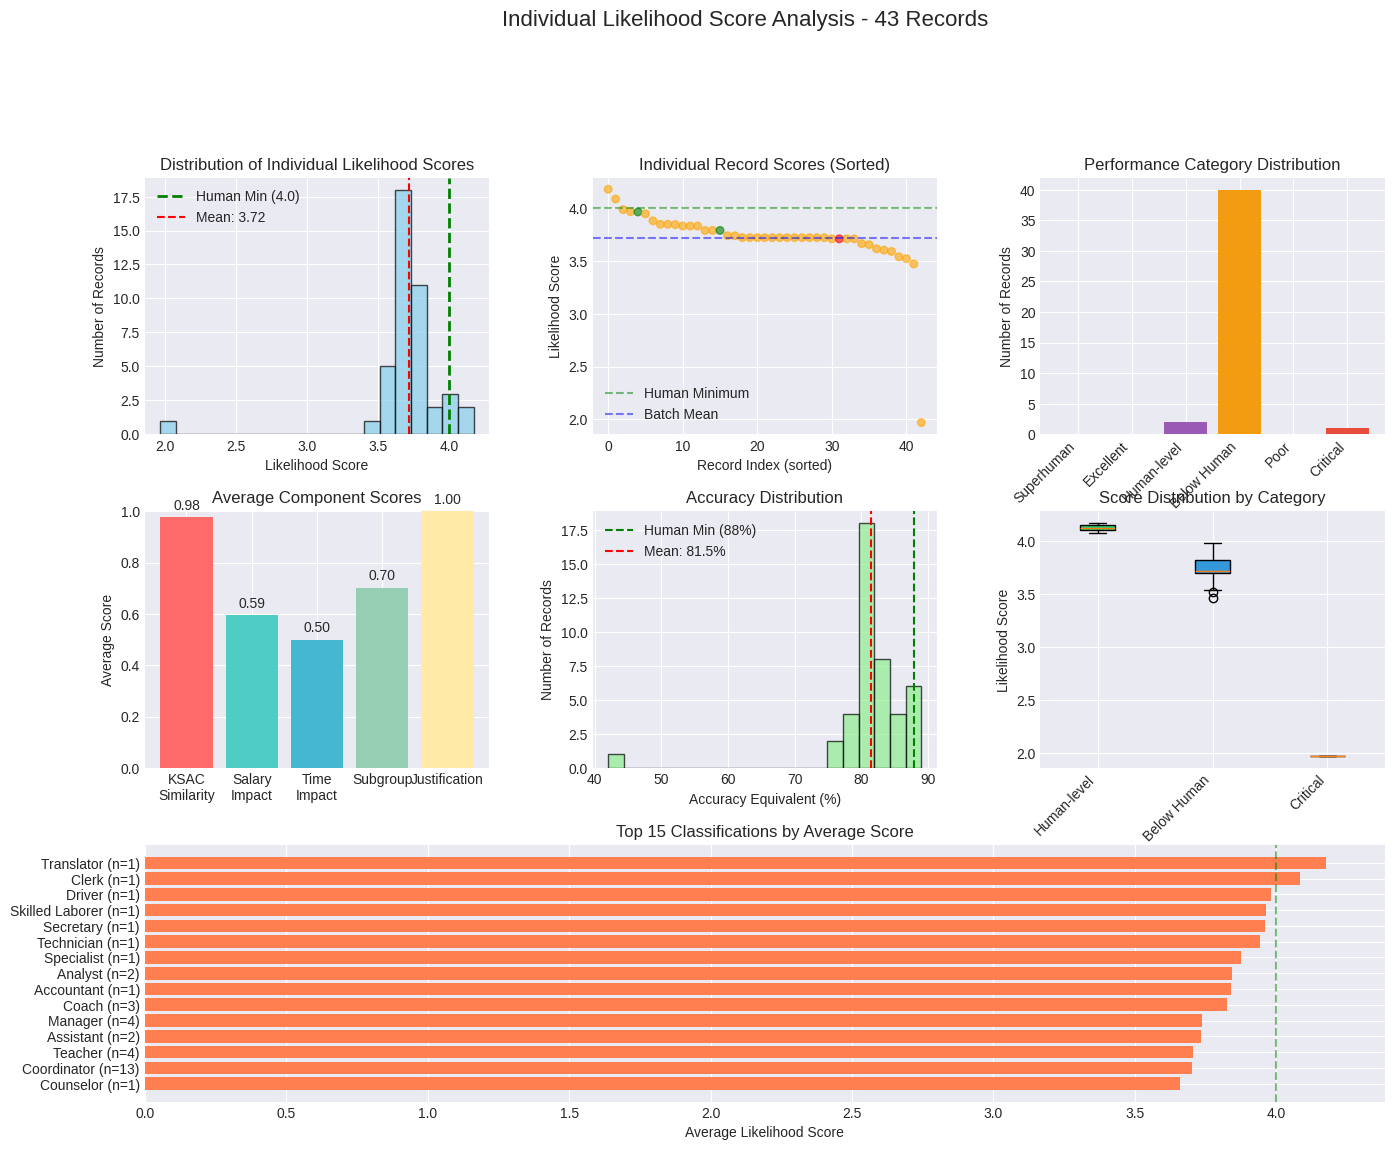


💾 Plots saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_20251117_213734/likelihood_analysis_plots.png


In [9]:
#@title 9️⃣ Generate Visualizations { display-mode: "form" }
#@markdown Create visual analysis of individual scores

# Create comprehensive visualizations
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Individual Score Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(results_df['likelihood_score'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(4.0, color='green', linestyle='--', linewidth=2, label='Human Min (4.0)')
ax1.axvline(results_df['likelihood_score'].mean(), color='red', linestyle='--', label=f'Mean: {results_df["likelihood_score"].mean():.2f}')
ax1.set_xlabel('Likelihood Score')
ax1.set_ylabel('Number of Records')
ax1.set_title('Distribution of Individual Likelihood Scores')
ax1.legend()

# 2. Scatter plot of all records
ax2 = fig.add_subplot(gs[0, 1])
colors = ['green' if x >= 4.0 else 'orange' if x >= 3.0 else 'red' for x in results_df['likelihood_score']]
ax2.scatter(range(len(results_df)), sorted_results['likelihood_score'].values, c=colors, alpha=0.6, s=30)
ax2.axhline(y=4.0, color='green', linestyle='--', alpha=0.5, label='Human Minimum')
ax2.axhline(y=results_df['likelihood_score'].mean(), color='blue', linestyle='--', alpha=0.5, label='Batch Mean')
ax2.set_xlabel('Record Index (sorted)')
ax2.set_ylabel('Likelihood Score')
ax2.set_title('Individual Record Scores (Sorted)')
ax2.legend()

# 3. Performance Category Distribution
ax3 = fig.add_subplot(gs[0, 2])
category_counts = results_df['performance_category'].value_counts()
categories = ["Superhuman", "Excellent", "Human-level", "Below Human", "Poor", "Critical"]
counts = [category_counts.get(cat, 0) for cat in categories]
colors_bar = ['#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#e67e22', '#e74c3c']
ax3.bar(categories, counts, color=colors_bar)
ax3.set_xlabel('Performance Category')
ax3.set_ylabel('Number of Records')
ax3.set_title('Performance Category Distribution')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Component Score Averages
ax4 = fig.add_subplot(gs[1, 0])
component_means = [
    results_df['similarity_score'].mean(),
    results_df['salary_score'].mean(),
    results_df['time_score'].mean(),
    results_df['subgroup_score'].mean(),
    results_df['justification_score'].mean()
]
components = ['KSAC\nSimilarity', 'Salary\nImpact', 'Time\nImpact', 'Subgroup', 'Justification']
bars = ax4.bar(components, component_means, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
ax4.set_ylabel('Average Score')
ax4.set_title('Average Component Scores')
ax4.set_ylim(0, 1)
for bar, score in zip(bars, component_means):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')

# 5. Accuracy Equivalent Distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(results_df['accuracy_equivalent'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
ax5.axvline(HUMAN_BASELINE_MIN, color='green', linestyle='--', label=f'Human Min ({HUMAN_BASELINE_MIN}%)')
ax5.axvline(results_df['accuracy_equivalent'].mean(), color='red', linestyle='--', label=f'Mean: {results_df["accuracy_equivalent"].mean():.1f}%')
ax5.set_xlabel('Accuracy Equivalent (%)')
ax5.set_ylabel('Number of Records')
ax5.set_title('Accuracy Distribution')
ax5.legend()

# 6. Box plot by performance category
ax6 = fig.add_subplot(gs[1, 2])
category_order = ["Superhuman", "Excellent", "Human-level", "Below Human", "Poor", "Critical"]
existing_categories = [cat for cat in category_order if cat in results_df['performance_category'].values]
data_for_box = [results_df[results_df['performance_category'] == cat]['likelihood_score'].values
                for cat in existing_categories]
bp = ax6.boxplot(data_for_box, labels=existing_categories, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_bar[:len(existing_categories)]):
    patch.set_facecolor(color)
ax6.set_ylabel('Likelihood Score')
ax6.set_title('Score Distribution by Category')
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 7. Heatmap of top classifications
ax7 = fig.add_subplot(gs[2, :])
role_scores = results_df.groupby('classification')['likelihood_score'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_roles = role_scores.head(15)
ax7.barh(range(len(top_roles)), top_roles['mean'].values, color='coral')
ax7.set_yticks(range(len(top_roles)))
ax7.set_yticklabels([f"{role[:30]} (n={int(count)})" for role, count in zip(top_roles.index, top_roles['count'].values)])
ax7.set_xlabel('Average Likelihood Score')
ax7.set_title('Top 15 Classifications by Average Score')
ax7.axvline(x=4.0, color='green', linestyle='--', alpha=0.5)
ax7.invert_yaxis()

plt.suptitle(f'Individual Likelihood Score Analysis - {len(results_df)} Records', fontsize=16, y=1.02)
plt.tight_layout()

# Save figure to Drive
plot_file = os.path.join(run_results_path, 'likelihood_analysis_plots.png')
plt.savefig(plot_file, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Plots saved to: {plot_file}")

In [10]:
#@title 10. Generate and Save Comprehensive Report { display-mode: "form" }
#@markdown Create detailed text report with all findings

report = f"""
{'='*80}
MNPS JOB CLASSIFICATION LIKELIHOOD ANALYSIS REPORT
Individual Record Scoring with Human Baseline: {HUMAN_BASELINE_MIN}%-{HUMAN_BASELINE_MAX}%
{'='*80}

RUN INFORMATION
---------------
Timestamp: {timestamp}
Total Records Analyzed: {len(results_df)}
Results Location: {run_results_path}

CONFIGURATION
-------------
Human Baseline Range: {HUMAN_BASELINE_MIN}%-{HUMAN_BASELINE_MAX}%
Human Typical Performance: {HUMAN_BASELINE_TYPICAL:.1f}%

Component Weights:
  • KSAC Similarity: {weights['similarity']*100:.1f}%
  • Salary Impact: {weights['salary']*100:.1f}%
  • Time Impact: {weights['time']*100:.1f}%
  • Subgroup: {weights['subgroup']*100:.1f}%
  • Justification: {weights['justification']*100:.1f}%

OVERALL PERFORMANCE
-------------------
Mean Likelihood Score: {results_df['likelihood_score'].mean():.2f} / 5.00
Median Likelihood Score: {results_df['likelihood_score'].median():.2f} / 5.00
Standard Deviation: {results_df['likelihood_score'].std():.2f}
Range: {results_df['likelihood_score'].min():.2f} - {results_df['likelihood_score'].max():.2f}

Accuracy Equivalent: {results_df['accuracy_equivalent'].mean():.1f}%
Gap to Human Minimum: {HUMAN_BASELINE_MIN - results_df['accuracy_equivalent'].mean():.1f}%

PERFORMANCE RELATIVE TO HUMAN BASELINE
---------------------------------------
Records at/above human minimum (≥4.0): {len(results_df[results_df['likelihood_score'] >= 4.0])} ({len(results_df[results_df['likelihood_score'] >= 4.0])/len(results_df)*100:.1f}%)
Records below human minimum (<4.0): {len(results_df[results_df['likelihood_score'] < 4.0])} ({len(results_df[results_df['likelihood_score'] < 4.0])/len(results_df)*100:.1f}%)

PERFORMANCE DISTRIBUTION
------------------------
"""

for category in ["Superhuman", "Excellent", "Human-level", "Below Human", "Poor", "Critical"]:
    count = len(results_df[results_df['performance_category'] == category])
    percentage = (count / len(results_df)) * 100
    report += f"{category:15}: {count:3} records ({percentage:5.1f}%)\n"

report += f"""
COMPONENT ANALYSIS
------------------
Average Component Scores (0-1 scale):
  • KSAC Similarity:       {results_df['similarity_score'].mean():.3f}
  • Salary Impact:         {results_df['salary_score'].mean():.3f}
  • Time Impact:           {results_df['time_score'].mean():.3f}
  • Subgroup Quality:      {results_df['subgroup_score'].mean():.3f}
  • Justification Quality: {results_df['justification_score'].mean():.3f}

TOP 10 BEST PERFORMING RECORDS
-------------------------------
"""

for i, (idx, row) in enumerate(sorted_results.head(10).iterrows(), 1):
    report += f"{i:2}. Score {row['likelihood_score']:.2f}: {row['job_title'][:40]} → {row['classification'][:30]}\n"

report += """
BOTTOM 10 WORST PERFORMING RECORDS
-----------------------------------
"""

for i, (idx, row) in enumerate(sorted_results.tail(10).iterrows(), 1):
    report += f"{i:2}. Score {row['likelihood_score']:.2f}: {row['job_title'][:40]} → {row['classification'][:30]}\n"

report += f"""
COST IMPLICATIONS
-----------------
Average Correction Time per Error: {resource_data['time_to_correct'].iloc[0]['Average']} hours
Estimated Error Rate: {100 - results_df['accuracy_equivalent'].mean():.1f}%
Estimated Errors in Batch: {len(results_df) * (100 - results_df['accuracy_equivalent'].mean()) / 100:.1f}
Total Correction Hours: {len(results_df) * (100 - results_df['accuracy_equivalent'].mean()) / 100 * resource_data['time_to_correct'].iloc[0]['Average']:.1f}
Estimated Correction Cost: ${len(results_df) * (100 - results_df['accuracy_equivalent'].mean()) / 100 * resource_data['time_to_correct'].iloc[0]['Average'] * 35:,.2f}

RECOMMENDATIONS
---------------
"""

if results_df['likelihood_score'].mean() >= 4.5:
    report += """✅ EXCELLENT: Model performs at or above typical human level.
   • Ready for production deployment with standard QA
   • Focus on maintaining consistency
   • Monitor edge cases"""
elif results_df['likelihood_score'].mean() >= 4.0:
    report += """✅ GOOD: Model meets minimum human performance standards.
   • Can be deployed with oversight for complex cases
   • Focus on lowest-scoring records for improvement
   • Implement confidence scoring"""
elif results_df['likelihood_score'].mean() >= 3.0:
    report += """⚠️ FAIR: Model is below human performance standards.
   • Suitable for initial screening only
   • Requires improvements before production use
   • Analyze patterns in low-scoring records"""
else:
    report += """❌ POOR: Model significantly underperforms human baseline.
   • Not recommended for production use
   • Consider fundamental model changes
   • Increase training data quality and quantity"""

report += f"""

FILES GENERATED
---------------
1. individual_likelihood_scores.csv - Detailed scores for each record
2. configuration.json - Run configuration settings
3. likelihood_analysis_plots.png - Visual analysis
4. analysis_report.txt - This report

All files saved to: {run_results_path}

{'='*80}
END OF REPORT
{'='*80}
"""

# Save report
report_file = os.path.join(run_results_path, 'analysis_report.txt')
with open(report_file, 'w') as f:
    f.write(report)

print(report)
print(f"\n💾 Report saved to: {report_file}")


MNPS JOB CLASSIFICATION LIKELIHOOD ANALYSIS REPORT
Individual Record Scoring with Human Baseline: 88%-94%

RUN INFORMATION
---------------
Timestamp: 20251117_213734
Total Records Analyzed: 43
Results Location: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_20251117_213734

CONFIGURATION
-------------
Human Baseline Range: 88%-94%
Human Typical Performance: 91.0%

Component Weights:
  • KSAC Similarity: 40.0%
  • Salary Impact: 20.0%
  • Time Impact: 10.0%
  • Subgroup: 15.0%
  • Justification: 15.0%

OVERALL PERFORMANCE
-------------------
Mean Likelihood Score: 3.72 / 5.00
Median Likelihood Score: 3.72 / 5.00
Standard Deviation: 0.31
Range: 1.97 - 4.17

Accuracy Equivalent: 81.5%
Gap to Human Minimum: 6.5%

PERFORMANCE RELATIVE TO HUMAN BASELINE
---------------------------------------
Records at/above human minimum (≥4.0): 2 (4.7%)
Records below human minimum (<4.0): 41 (95.3%)

PERFORMANCE DISTRIBUTION
------------------------
Superhuman     :   0 records (  0.0%)
Exce

In [11]:
#@title 11. Download Results (Optional) { display-mode: "form" }
#@markdown Download the results to your local machine

download_files = True #@param {type:"boolean"}

if download_files:
    print("📥 Preparing files for download...\n")

    # Files to download
    files_to_download = [
        os.path.join(run_results_path, 'individual_likelihood_scores.csv'),
        os.path.join(run_results_path, 'analysis_report.txt'),
        os.path.join(run_results_path, 'configuration.json')
    ]

    for file_path in files_to_download:
        if os.path.exists(file_path):
            print(f"Downloading: {os.path.basename(file_path)}")
            files.download(file_path)

    print("\n✅ Files downloaded!")
else:
    print("ℹ️ Files are saved in Google Drive. No local download requested.")

print(f"\n📂 All results saved to Google Drive at:")
print(f"   {run_results_path}")

📥 Preparing files for download...

Downloading: individual_likelihood_scores.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: analysis_report.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: configuration.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Files downloaded!

📂 All results saved to Google Drive at:
   /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_20251117_213734


---

## 📚 Quick Reference Guide

### Likelihood Score Scale:
- **5.00**: Perfect accuracy (100%)
- **4.75+**: Superhuman (>94% accuracy)
- **4.50+**: Excellent (91% typical human)
- **4.00+**: Human-level (88% minimum human)
- **3.00+**: Below human standard
- **2.00+**: Poor performance
- **<2.00**: Critical issues

### What Each Score Means:
- **Score 4.0+**: Can replace human classification with spot checks
- **Score 3.5+**: Useful for initial screening, needs human review
- **Score 3.0+**: Helpful for data extraction, not decision-making
- **Score <3.0**: Requires significant improvements

### Using This Notebook for Future Batches:
1. Run cells 1-3 to set up environment and configuration
2. Upload resource zip file once (Cell 4)
3. Upload new input files for each batch (Cell 5)
4. Run remaining cells to analyze
5. Results automatically saved to Google Drive

### Files Structure in Google Drive:
```
MNPS_Likelihood_Analysis/
├── Resources/          # Static resource files
├── Inputs/            # Input files from each run
└── Results/           # Results organized by timestamp
    └── Run_YYYYMMDD_HHMMSS/
        ├── individual_likelihood_scores.csv
        ├── analysis_report.txt
        ├── configuration.json
        └── likelihood_analysis_plots.png
```

---

**Created by**: MNPS HR Analytics Team  
**Version**: 2.0  
**Last Updated**: November 2024